###1.Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2.Load the dataset

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)
df = pd.read_csv(os.path.join(path,"AB_NYC_2019.csv"))
df.head()

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.shape

(48895, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## 3.EDA

In [6]:
missing  = df.isnull().mean()*100
(missing[missing>0])

,0
name,0.032723
host_name,0.042949
last_review,20.558339
reviews_per_month,20.558339


In [7]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [8]:
df['room_type'].value_counts()

,count
room_type,
Entire home/apt,25409
Private room,22326
Shared room,1160


<Axes: xlabel='room_type', ylabel='count'>

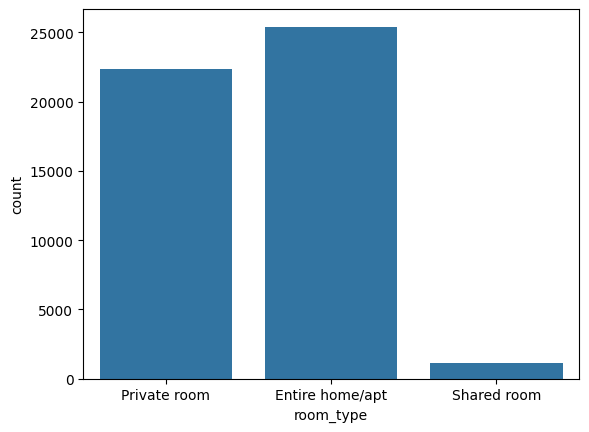

In [9]:
sns.countplot(x='room_type',data=df)

#####class imbalance of target label

In [10]:
numerical_cols = ['price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365']

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

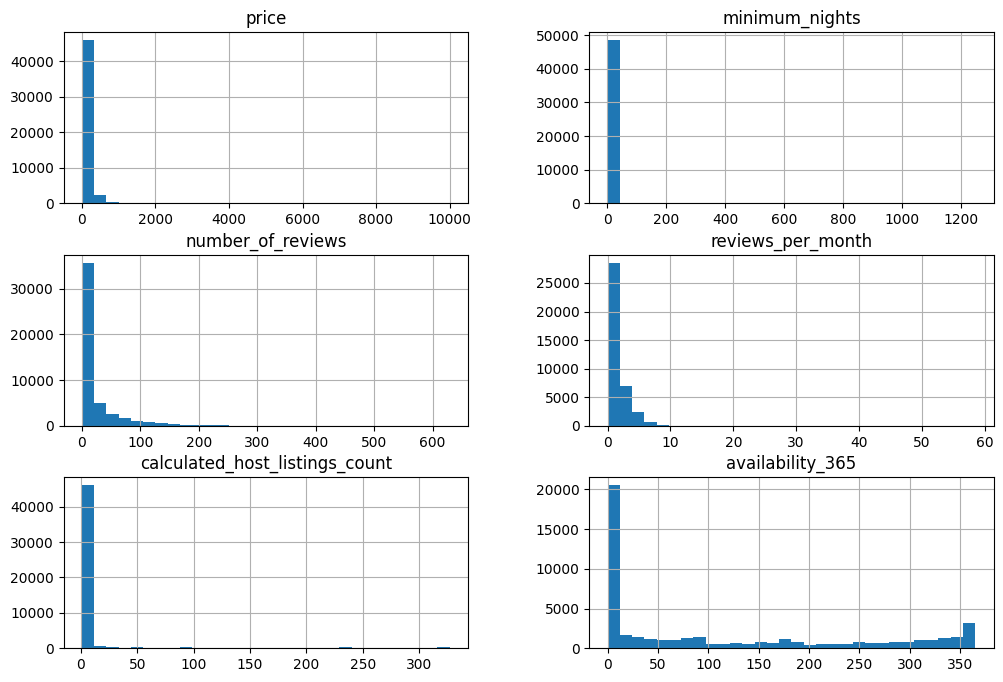

In [11]:
df[numerical_cols].hist(bins=30,figsize=(12,8))

<Axes: xlabel='room_type', ylabel='price'>

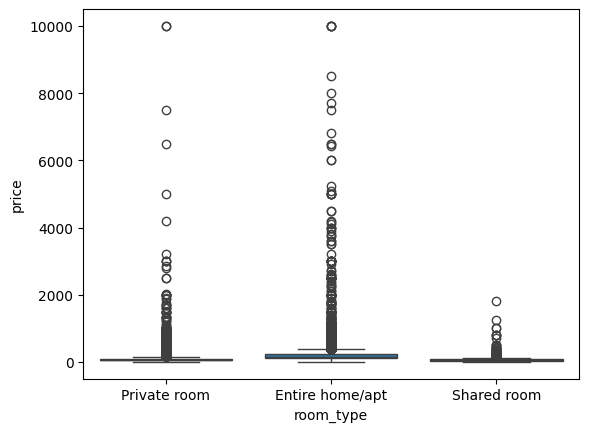

In [12]:
sns.boxplot(x='room_type',y='price',data=df)

<Axes: xlabel='neighbourhood_group', ylabel='price'>

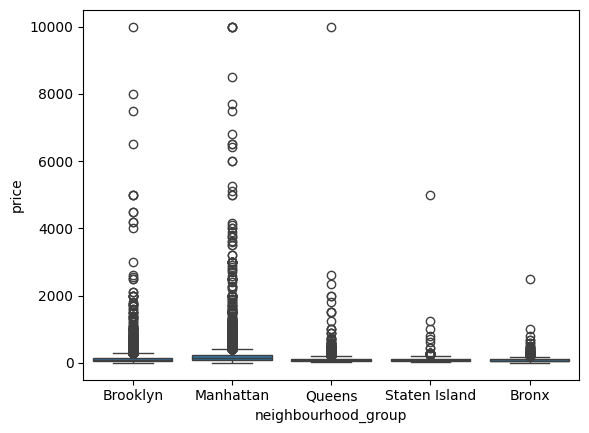

In [13]:
sns.boxplot(x='neighbourhood_group',y='price',data=df)

<Axes: xlabel='availability_365', ylabel='price'>

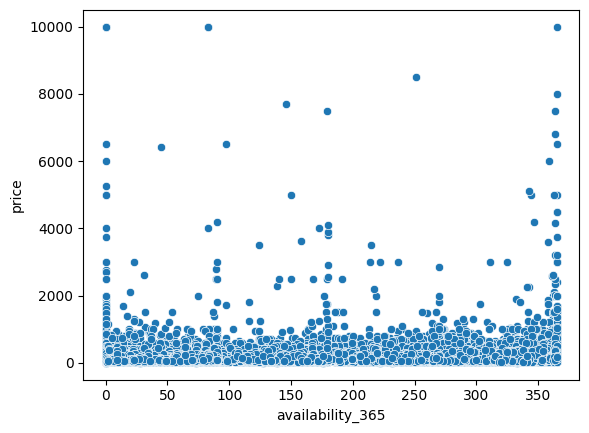

In [14]:
sns.scatterplot(data=df, x="availability_365", y="price")

<Axes: >

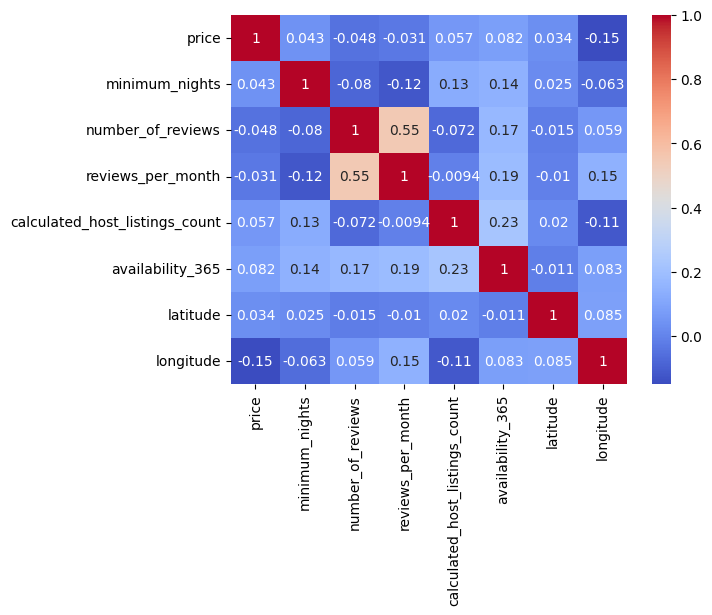

In [15]:
corr = df[numerical_cols + ['latitude','longitude']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')


<Axes: xlabel='latitude', ylabel='longitude'>

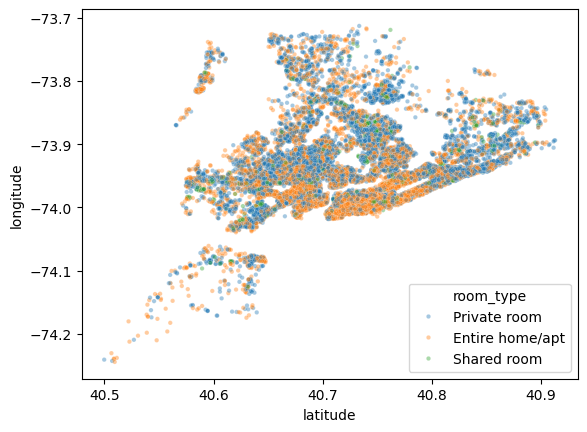

In [16]:
sns.scatterplot(x='latitude',y='longitude',hue='room_type',data=df,alpha=0.4,s=10)

## 4. Data cleaning and Feature engineering

In [17]:
#dropping irrelevant columns
df_clean = df.drop(columns = ['id','name','host_id','host_name','last_review'])
# missing values in reveiws_per_month is not actually missing but 0
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)
df_clean.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [18]:
df_clean.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


some extreme outliers like in price : 0 and 10000   

minimum_nights , min = 1 , max = 1250 with mean 7

In [19]:
# cap the exteme outliers
price_cap  = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)
print(price_cap,nights_cap)
df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=nights_cap)
df_clean.describe()


799.0 45.0


,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,143.956233,6.116760,23.274466,1.090910,7.143982,112.781327
std,0.054530,0.046157,121.935067,9.244957,44.550582,1.597283,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,40.913060,-73.712990,799.000000,45.000000,629.000000,58.500000,327.000000,365.000000


In [20]:
X = df_clean.drop(columns = ['room_type'])
y = df_clean['room_type']
X.shape

(48895, 10)

## 5.Train Test Split

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

##6.Preprocessing : columntransformer + pipeline

In [22]:
df_clean[numerical_cols].skew()

,0
price,2.776321
minimum_nights,2.360347
number_of_reviews,3.690635
reviews_per_month,3.300723
calculated_host_listings_count,7.933174
availability_365,0.763408


In [23]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer

In [24]:
numerical_cols = ['latitude','longitude','price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365']
categorical_cols = ['neighbourhood_group','neighbourhood']

#1 pipeline for numeric columns
numeric_pipeline = Pipeline(steps=[
    ('imputing', SimpleImputer(strategy='median')),

    ('scaling', StandardScaler())
])

#2 pipeline for categorical columns
categoric_pipeline = Pipeline(steps=[
    ('imputing', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numerical_cols),
        ('cat', categoric_pipeline, categorical_cols)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputing',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaling',
                                                  StandardScaler())]),
                                 ['latitude', 'longitude', 'price',
                                  'minimum_nights', 'number_of_reviews',
                                  'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365']),
                                ('cat',
                                 Pipeline(steps=[('imputing',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

## 7. Trying multiple algos

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.model_selection import cross_val_score


In [28]:
models = {
    'LogisticRegression' : LogisticRegression(class_weight='balanced',max_iter=2000,random_state=42,solver='lbfgs'),
    'DecisionTreeClassifier' : DecisionTreeClassifier(class_weight='balanced',random_state=42),
    'RandomForestClassifier' : RandomForestClassifier(class_weight='balanced',random_state=42),
    'GradientBoostingClassifier' : GradientBoostingClassifier()
}
for name,model in models.items():
  pipe = Pipeline(steps=[
      ('preprocessor',preprocessor),
      ('classifier',model)
  ])
  accuracy = cross_val_score(pipe,X_train,y_train,cv=5,scoring='accuracy')
  macrof1 = cross_val_score(pipe,X_train,y_train,cv=5,scoring='f1_macro')
  print(f"{name} -> Accuracy: {accuracy.mean():.3f} , F1: {macrof1.mean():.3f}")


LogisticRegression -> Accuracy: 0.662 , F1: 0.525
DecisionTreeClassifier -> Accuracy: 0.788 , F1: 0.658
RandomForestClassifier -> Accuracy: 0.854 , F1: 0.720
GradientBoostingClassifier -> Accuracy: 0.851 , F1: 0.705


##8. Hyperparameter tuning

In [29]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(class_weight='balanced'))
])

param_distribution = {
    "classifier__n_estimators" : [100,200,150,300],
    "classifier__max_depth": [8, 12, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
}

search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42
    )

search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputing',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaling',
                                                                                                StandardScaler())]),
                                                                               ['latitude',
                                                                                'longitude',
                                                                                'price',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
                                                                                'reviews_per_month',
                                                                                'calculated_host_listings_count',
                                                                                'availability_365']),
                                                                              ('cat',
                                                                               Pi...
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['neighbourhood_group',
                                                                                'neighbourhood'])])),
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced'))]),
                   param_distributions={'classifier__max_depth': [8, 12, 15, 20,
                                                                  None],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     150,
                                                                     300]},
                   random_state=42, scoring='f1_macro')

In [31]:
print("Best parameters: ",search.best_params_)
print("Best score: ",search.best_score_)

Best parameters:  {'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__max_depth': None}
Best score:  0.7357370158890474


##9.Final Evaluaation on the test set

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix,f1_score
best_pipeline = search.best_estimator_

y_pred = best_pipeline.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred, average="macro")}")

Accuracy Score: 0.8570405971980775
F1 Score: 0.7543202920886714


<Axes: >

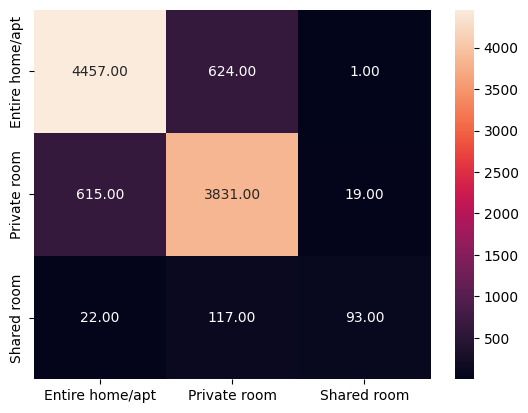

In [35]:
from sklearn.metrics import classification_report , confusion_matrix,accuracy_score,f1_score

sns.heatmap(confusion_matrix(y_test,y_pred),annot= True,fmt='.2f',
            xticklabels=best_pipeline.classes_,yticklabels=best_pipeline.classes_)

##10.Save the model

In [36]:
import joblib
joblib.dump(best_pipeline,'Model_pipeline.pkl')

['Model_pipeline.pkl']

In [37]:
df_clean.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')